In [28]:
# ==============================================================================
# PREPARACIÓN DEL ENTORNO Y FUNCIONES AUXILIARES
# ==============================================================================

import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

# Función robusta para cargar imágenes en el Bloque 1 (mantiene proporción)
def cargar_imagen(ruta, max_dim=512):
    img = tf.io.read_file(ruta)
    # decode_image evita problemas con falsos .jpg
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)

    # Cálculo estricto de proporciones
    shape = tf.shape(img)
    h = tf.cast(shape[0], tf.float32)
    w = tf.cast(shape[1], tf.float32)
    escala = max_dim / tf.maximum(h, w)

    nuevo_h = tf.cast(h * escala, tf.int32)
    nuevo_w = tf.cast(w * escala, tf.int32)

    img = tf.image.resize(img, [nuevo_h, nuevo_w])
    return img[tf.newaxis, :] # Añadir dimensión de lote [1, H, W, 3]

# Función para mostrar los resultados alineados
def mostrar_resultado(contenido, estilo, resultado, titulo):
    plt.figure(figsize=(15, 5))
    plt.suptitle(titulo, fontsize=16)

    plt.subplot(1, 3, 1)
    plt.imshow(tf.squeeze(contenido))
    plt.title("Contenido")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(tf.squeeze(estilo))
    plt.title("Estilo")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(tf.squeeze(resultado))
    plt.title("Resultado")
    plt.axis('off')
    plt.show()

# Cargar imágenes para el Bloque 1 (Asegúrate de que los archivos se llaman así)
img_contenido = cargar_imagen('contenido.jpg')
img_estilo = cargar_imagen('estilo.jpg')

Descargando e inicializando modelo preentrenado de Magenta...
Realizando inferencia...


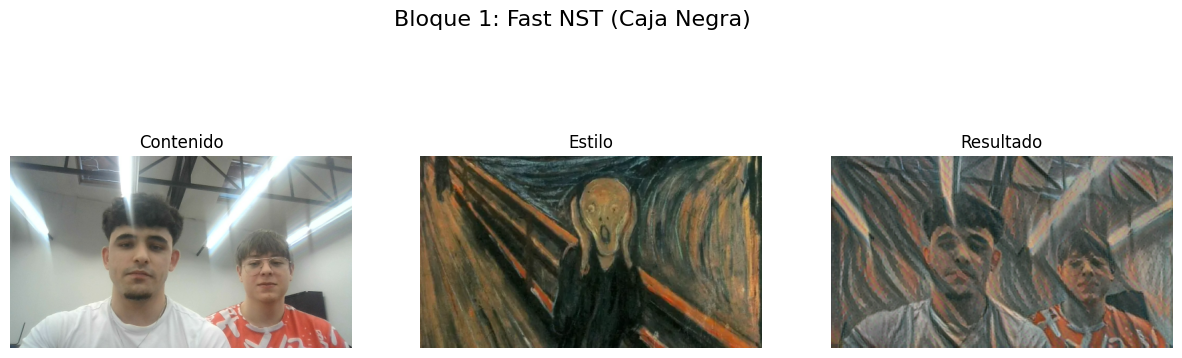

In [29]:
# ==============================================================================
# BLOQUE 1: Inferencia Rápida (Fast NST) con TensorFlow Hub
# ==============================================================================

print("Descargando e inicializando modelo preentrenado de Magenta...")
hub_url = 'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'
modelo_rapido = hub.load(hub_url)

print("Realizando inferencia...")
# Pasamos los tensores al modelo y extraemos el tensor resultante [0]
resultado_hub = modelo_rapido(tf.constant(img_contenido), tf.constant(img_estilo))[0]

mostrar_resultado(img_contenido, img_estilo, resultado_hub, "Bloque 1: Fast NST (Caja Negra)")

In [30]:
# ==============================================================================
# BLOQUE 2 (Preparación): Aislamiento VGG19 y Extracción
# ==============================================================================

# 1. Armonización Simétrica Estricta a 512x512
def cargar_imagen_cuadrada(ruta, size=512):
    img = tf.io.read_file(ruta)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [size, size])
    # Forzar el tensor estrictamente a 4 dimensiones para evitar fallos de shape
    img = tf.reshape(img, [1, size, size, 3])
    return img

cont_512 = cargar_imagen_cuadrada('contenido.jpg')
estilo_512 = cargar_imagen_cuadrada('estilo.jpg')

# 2. VGG19 Nativa Congelada
print("Cargando VGG19 de Keras...")
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

capas_estilo = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']
capa_contenido = ['block4_conv2']

salidas = [vgg.get_layer(nombre).output for nombre in (capas_estilo + capa_contenido)]
extractor = tf.keras.Model([vgg.input], salidas)

# 3. Matemáticas
def matriz_gram(tensor):
    resultado = tf.linalg.einsum('bijc,bijd->bcd', tensor, tensor)
    shape = tf.shape(tensor)
    num_elementos = tf.cast(shape[1] * shape[2], tf.float32)
    return resultado / num_elementos

def extraer_caracteristicas(imagen_tensor):
    salidas = extractor(imagen_tensor)
    caract_estilo = [matriz_gram(estilo) for estilo in salidas[:len(capas_estilo)]]
    caract_contenido = salidas[len(capas_estilo):]
    return caract_estilo, caract_contenido

targets_estilo, _ = extraer_caracteristicas(estilo_512)
_, targets_contenido = extraer_caracteristicas(cont_512)

Cargando VGG19 de Keras...


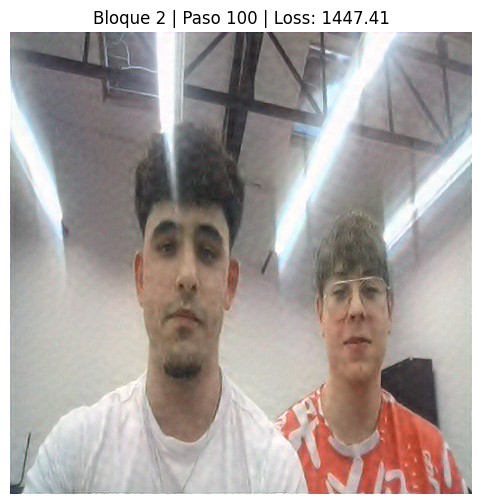

In [31]:
# ==============================================================================
# BLOQUE 2 (Ejecución): Bucle de optimización explícita
# ==============================================================================

# Inicializamos el lienzo modificable a partir de la foto de contenido
lienzo = tf.Variable(cont_512)
optimizador = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

peso_estilo = 1e-2
peso_contenido = 1e4

@tf.function
def paso_entrenamiento(imagen):
    with tf.GradientTape() as tape:
        salidas_estilo, salidas_contenido = extraer_caracteristicas(imagen)

        loss_cont = tf.add_n([tf.reduce_mean((salidas_contenido[i] - targets_contenido[i])**2) for i in range(len(salidas_contenido))])
        loss_est = tf.add_n([tf.reduce_mean((salidas_estilo[i] - targets_estilo[i])**2) for i in range(len(salidas_estilo))])

        loss_total = (peso_contenido * loss_cont) + (peso_estilo * loss_est)

    gradientes = tape.gradient(loss_total, imagen)
    optimizador.apply_gradients([(gradientes, imagen)])
    imagen.assign(tf.clip_by_value(imagen, clip_value_min=0.0, clip_value_max=1.0))
    return loss_total

pasos = 100
for n in range(pasos + 1):
    loss = paso_entrenamiento(lienzo)
    if n % 10 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(tf.squeeze(lienzo.read_value()))
        plt.title(f"Bloque 2 | Paso {n} | Loss: {loss:.2f}")
        plt.axis('off')
        plt.show()

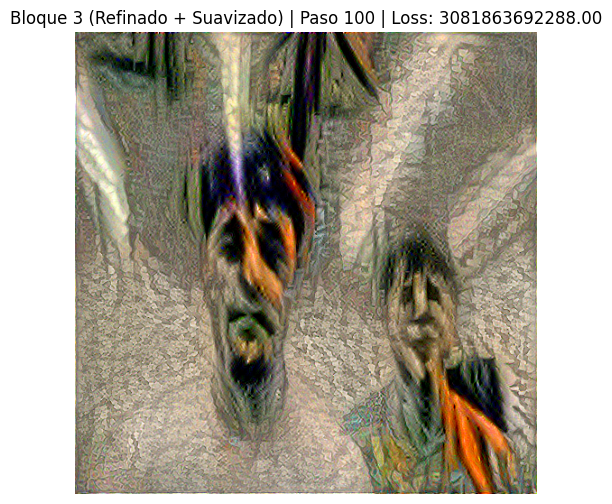

In [33]:
# ==============================================================================
# BLOQUE 3: Optimización Refinada (AveragePooling + Preprocess + Suavizado TV)
# ==============================================================================

import tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 1. Reconstrucción Segura de VGG19 (Clonación explícita)
vgg_base = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
entradas = tf.keras.Input(shape=(512, 512, 3))
x = entradas

salidas_dict = {}

for capa in vgg_base.layers[1:]:
    if 'pool' in capa.name:
        x = tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2), name=capa.name)(x)
    else:
        config = capa.get_config()
        nueva_capa = capa.__class__.from_config(config)
        x = nueva_capa(x)
        nueva_capa.set_weights(capa.get_weights())

    salidas_dict[capa.name] = x

# 2. Extractor Mejorado
salidas_finales = [salidas_dict[nombre] for nombre in (capas_estilo + capa_contenido)]
extractor_mejorado = tf.keras.Model(inputs=entradas, outputs=salidas_finales)
extractor_mejorado.trainable = False

# 3. Función de extracción auditada matemáticamente
def extraer_caracteristicas_mejoradas(imagen_tensor):
    imagen_procesada = imagen_tensor * 255.0
    imagen_procesada = tf.keras.applications.vgg19.preprocess_input(imagen_procesada)

    salidas = extractor_mejorado(imagen_procesada)
    caract_estilo = [matriz_gram(estilo) for estilo in salidas[:len(capas_estilo)]]
    caract_contenido = salidas[len(capas_estilo):]
    return caract_estilo, caract_contenido

targets_estilo_mej, _ = extraer_caracteristicas_mejoradas(estilo_512)
_, targets_contenido_mej = extraer_caracteristicas_mejoradas(cont_512)

# 4. Configuración final y PESOS AJUSTADOS
lienzo_mejorado = tf.Variable(cont_512)
optimizador_mej = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

# Pesos calibrados para emular la suavidad del Bloque 1 y el estilo fluido
peso_contenido = 1e1
peso_estilo = 5e4        # Subimos el peso del estilo para que las pinceladas dominen más
peso_suavizado = 20.0    # Peso de la Variación Total (TV) para eliminar ruido

@tf.function
def paso_entrenamiento_mejorado(imagen):
    with tf.GradientTape() as tape:
        salidas_estilo, salidas_contenido = extraer_caracteristicas_mejoradas(imagen)

        # Pérdidas clásicas
        loss_cont = tf.add_n([tf.reduce_mean((salidas_contenido[i] - targets_contenido_mej[i])**2) for i in range(len(salidas_contenido))])
        loss_est = tf.add_n([tf.reduce_mean((salidas_estilo[i] - targets_estilo_mej[i])**2) for i in range(len(salidas_estilo))])

        # NUEVO: Regularización de Variación Total (Suavizado de ruido)
        loss_tv = tf.reduce_sum(tf.image.total_variation(imagen))

        # Ecuación total con el suavizador integrado
        loss_total = (peso_contenido * loss_cont) + (peso_estilo * loss_est) + (peso_suavizado * loss_tv)

    gradientes = tape.gradient(loss_total, imagen)
    optimizador_mej.apply_gradients([(gradientes, imagen)])
    imagen.assign(tf.clip_by_value(imagen, clip_value_min=0.0, clip_value_max=1.0))
    return loss_total

# 5. Ejecución visual Bloque 3
pasos = 100
print("Iniciando optimización refinada con Suavizado Total Variation...")
for n in range(pasos + 1):
    loss = paso_entrenamiento_mejorado(lienzo_mejorado)
    if n % 10 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(tf.squeeze(lienzo_mejorado.read_value()))
        plt.title(f"Bloque 3 (Refinado + Suavizado) | Paso {n} | Loss: {loss:.2f}")
        plt.axis('off')
        plt.show()